# BTC-Anchored Crypto Pairs Trading:

## What this notebook does
1. Builds a **large-cap exploratory universe** from CoinGecko and Binance USDT listings.
2. Downloads **15-minute spot close prices** from Binance.
3. Applies a **rolling Engle–Granger cointegration screen** to rank BTC pairs and keep the top candidates.
4. Runs an **explicit walk-forward train/test pipeline**:
   - estimate Kalman hedge ratio on the **training window only**
   - test the training spread for stationarity
   - fit OU parameters on the **training window only**
   - optimize signal parameters on the **training window only**
   - freeze parameters and evaluate on the **next test window only**
4. Uses a **one-bar execution lag** in the backtest to avoid same-bar lookahead.
5. Stores **per-window optimization summaries** for auditability in the research paper.

## Research notes
- This is an **exploratory** universe construction procedure and may contain **survivorship / availability bias**.
- Results should be interpreted as **standalone pair backtests**, unless a true portfolio allocation layer is added.
- Funding, liquidation effects, and richer execution frictions are **not** modeled here.


In [13]:
import requests
import pandas as pd
import numpy as np
import datetime
import statsmodels.api as sm
import matplotlib.pyplot as plt

from binance.client import Client
from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (12, 4)


## Universe construction

In [14]:
# Pull top market-cap crypto assets from CoinGecko, excluding stablecoins and wrapped assets
url = "https://api.coingecko.com/api/v3/coins/markets"
params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50,
    "page": 1,
    "sparkline": False,
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()
data = response.json()

universe_df = pd.DataFrame(data)[
    ["market_cap_rank", "symbol", "name", "market_cap", "current_price"]
].copy()

stablecoins = {
    "usdt", "usdc", "busd", "dai", "tusd", "usdp", "fdusd", "gusd", "lusd",
    "ust", "ustc", "usdd", "eurc", "usds", "usde", "bsc-usd", "usd1", "pyusd"
}

universe_df["symbol"] = universe_df["symbol"].str.lower()
universe_df["name"] = universe_df["name"].str.lower()

universe_df = universe_df[~universe_df["symbol"].isin(stablecoins)]
universe_df = universe_df[
    ~universe_df["name"].str.contains("wrapped", na=False)
    & ~universe_df["symbol"].str.startswith("w")
]

universe_df = universe_df.sort_values("market_cap", ascending=False).head(20).reset_index(drop=True)
universe_df


,market_cap_rank,symbol,name,market_cap,current_price
0,1,btc,bitcoin,1336638910508,66851.000000
1,2,eth,ethereum,248352186099,2059.930000
2,4,bnb,bnb,83009392439,608.680000
3,5,xrp,xrp,80746218052,1.320000
4,7,sol,solana,46352041501,80.930000
5,8,trx,tron,29494130724,0.311220
6,9,figr_heloc,figure heloc,16482378582,1.012000
7,10,doge,dogecoin,13892450921,0.090414
8,13,bch,bitcoin cash,9408841850,469.970000
9,14,leo,leo token,9190292945,9.980000


In [15]:
# Keep only assets that trade against USDT on Binance
exchange_info = requests.get("https://api.binance.com/api/v3/exchangeInfo", timeout=30).json()
binance_assets = {
    s["baseAsset"].lower()
    for s in exchange_info["symbols"]
    if s["quoteAsset"] == "USDT" and s["status"] == "TRADING"
}

universe_df = universe_df[universe_df["symbol"].isin(binance_assets)].reset_index(drop=True)
display(universe_df)

client = Client()

def get_close_prices_15m(client, symbols, start_date, end_date):
    close_dfs = []

    for sym in symbols:
        pair = sym.upper() + "USDT"
        print(f"Downloading {pair}")

        start_ms = int(start_date.timestamp() * 1000)
        end_ms = int(end_date.timestamp() * 1000)

        klines = client.get_historical_klines(
            pair,
            Client.KLINE_INTERVAL_15MINUTE,
            start_ms,
            end_ms,
        )

        df = pd.DataFrame(
            klines,
            columns=[
                "timestamp", "open", "high", "low", "close", "volume",
                "close_time", "quote_asset_volume", "number_of_trades",
                "taker_buy_base", "taker_buy_quote", "ignore",
            ],
        )
        df = df[["timestamp", "close"]].copy()
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        df["close"] = df["close"].astype(float)
        df = df.rename(columns={"close": sym.upper()})
        close_dfs.append(df)

    if not close_dfs:
        raise ValueError("No price data downloaded.")

    df_close = close_dfs[0]
    for d in close_dfs[1:]:
        df_close = df_close.merge(d, on="timestamp", how="outer")

    df_close = df_close.sort_values("timestamp").set_index("timestamp")
    return df_close

end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=90)

df_close_15m = get_close_prices_15m(
    client=client,
    symbols=universe_df["symbol"].tolist(),
    start_date=start_date,
    end_date=end_date,
)

df_close_15m.head()


,market_cap_rank,symbol,name,market_cap,current_price
0,1,btc,bitcoin,1336638910508,66851.000000
1,2,eth,ethereum,248352186099,2059.930000
2,4,bnb,bnb,83009392439,608.680000
3,5,xrp,xrp,80746218052,1.320000
4,7,sol,solana,46352041501,80.930000
5,8,trx,tron,29494130724,0.311220
6,10,doge,dogecoin,13892450921,0.090414
7,13,bch,bitcoin cash,9408841850,469.970000
8,15,ada,cardano,8783921213,0.238082
9,17,link,chainlink,6114889873,8.640000


,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,BCH,ADA,LINK,XLM,ZEC,LTC
timestamp,,,,,,,,,,,,,
2025-12-31 16:15:00,87924.21,2987.50,862.27,1.8555,125.36,0.2835,0.12098,594.8,0.3412,12.39,0.2034,508.99,77.40
2025-12-31 16:30:00,87459.84,2966.70,859.27,1.8463,124.56,0.2838,0.11837,595.3,0.3341,12.27,0.2003,506.45,76.94
2025-12-31 16:45:00,87656.98,2976.03,861.58,1.8442,124.84,0.2837,0.11900,595.7,0.3336,12.29,0.2002,507.76,76.93
2025-12-31 17:00:00,87529.99,2970.64,861.82,1.8382,124.66,0.2839,0.11856,596.5,0.3334,12.26,0.1998,508.14,76.73
2025-12-31 17:15:00,87610.63,2975.40,862.40,1.8422,125.00,0.2836,0.11862,599.6,0.3351,12.28,0.2001,510.05,76.74


## Preprocessing and quick diagnostics

In [16]:
# Basic preprocessing
base = df_close_15m.iloc[0]
bad_cols = base[(base.isna()) | (base == 0)].index.tolist()
print("Dropping columns with invalid first observation:", bad_cols)

prices = df_close_15m.drop(columns=bad_cols).copy()
prices = prices.dropna(axis=0).sort_index()

print("Final sample shape:", prices.shape)
print("Date range:", prices.index.min(), "to", prices.index.max())
print("Columns:", list(prices.columns))
prices.head()


Dropping columns with invalid first observation: []
Final sample shape: (8640, 13)
Date range: 2025-12-31 16:15:00 to 2026-03-31 16:00:00
Columns: ['BTC', 'ETH', 'BNB', 'XRP', 'SOL', 'TRX', 'DOGE', 'BCH', 'ADA', 'LINK', 'XLM', 'ZEC', 'LTC']


,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,BCH,ADA,LINK,XLM,ZEC,LTC
timestamp,,,,,,,,,,,,,
2025-12-31 16:15:00,87924.21,2987.50,862.27,1.8555,125.36,0.2835,0.12098,594.8,0.3412,12.39,0.2034,508.99,77.40
2025-12-31 16:30:00,87459.84,2966.70,859.27,1.8463,124.56,0.2838,0.11837,595.3,0.3341,12.27,0.2003,506.45,76.94
2025-12-31 16:45:00,87656.98,2976.03,861.58,1.8442,124.84,0.2837,0.11900,595.7,0.3336,12.29,0.2002,507.76,76.93
2025-12-31 17:00:00,87529.99,2970.64,861.82,1.8382,124.66,0.2839,0.11856,596.5,0.3334,12.26,0.1998,508.14,76.73
2025-12-31 17:15:00,87610.63,2975.40,862.40,1.8422,125.00,0.2836,0.11862,599.6,0.3351,12.28,0.2001,510.05,76.74


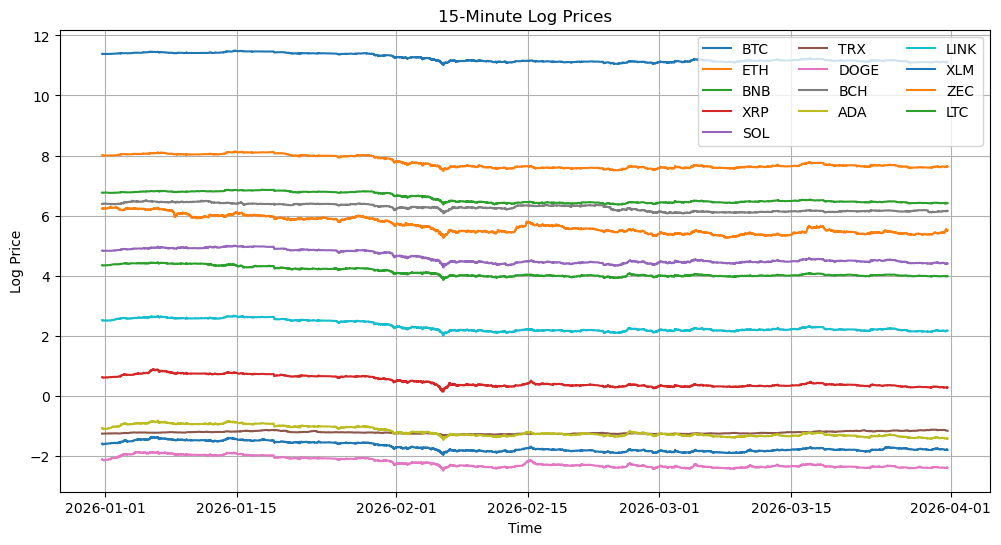

In [17]:
log_prices = np.log(prices)

plt.figure(figsize=(12, 6))
for col in log_prices.columns:
    plt.plot(log_prices.index, log_prices[col], label=col)
plt.title("15-Minute Log Prices")
plt.xlabel("Time")
plt.ylabel("Log Price")
plt.legend(loc="best", ncol=3)
plt.grid(True)
plt.show()


## Strategy functions

In [ ]:
def kalman_hedge_ratio(
    series_x: pd.Series,
    series_y: pd.Series,
    delta: float = 1e-4,
    obs_var: float = 1.0,
):
    idx = series_x.index.intersection(series_y.index)
    x = series_x.loc[idx].astype(float)
    y = series_y.loc[idx].astype(float)

    state_mean = np.zeros(2, dtype=float)
    state_cov = np.eye(2, dtype=float)
    Q = (delta / max(1e-12, 1.0 - delta)) * np.eye(2, dtype=float)
    R = float(obs_var)

    alpha = np.zeros(len(idx), dtype=float)
    beta = np.zeros(len(idx), dtype=float)

    for i, (xt, yt) in enumerate(zip(x.values, y.values)):
        H = np.array([[1.0, xt]], dtype=float)
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q

        y_pred = (H @ state_mean_pred).item()
        err = yt - y_pred
        S = (H @ state_cov_pred @ H.T).item() + R
        K = (state_cov_pred @ H.T) / S

        state_mean = state_mean_pred + (K.flatten() * err)
        state_cov = (np.eye(2) - K @ H) @ state_cov_pred

        alpha[i] = state_mean[0]
        beta[i] = state_mean[1]

    alpha_s = pd.Series(alpha, index=idx, name="alpha")
    beta_s = pd.Series(beta, index=idx, name="beta")
    spread = y - (alpha_s + beta_s * x)

    spread_clean = spread.dropna()
    if len(spread_clean) >= 20:
        adf = adfuller(spread_clean)
        t_stat = adf[0]
        pvalue = adf[1]
        crit = adf[4]
    else:
        t_stat = np.nan
        pvalue = np.nan
        crit = {"1%": np.nan, "5%": np.nan, "10%": np.nan}

    return {
        "alpha_series": alpha_s,
        "beta_series": beta_s,
        "latest_alpha": float(alpha_s.iloc[-1]),
        "latest_beta": float(beta_s.iloc[-1]),
        "spread": spread,
        "pvalue": pvalue,
        "t_stat": t_stat,
        "crit_1%": crit["1%"],
        "crit_5%": crit["5%"],
        "crit_10%": crit["10%"],
    }


def fit_ou_from_spread(spread: pd.Series, dt: float = 1.0):
    s = spread.dropna().astype(float)
    if len(s) < 30:
        return None

    s_t = s.iloc[:-1].values
    s_t1 = s.iloc[1:].values
    X = sm.add_constant(s_t)
    res = sm.OLS(s_t1, X).fit()

    b = float(res.params[0])
    a = float(res.params[1])

    if not (0 < a < 1):
        return None

    kappa = -np.log(a) / dt
    mu = b / (1 - a)
    resid = res.resid
    sigma_eq = np.std(resid, ddof=1) / np.sqrt(max(1e-12, 1 - a**2))
    half_life = np.log(2) / kappa if kappa > 0 else np.inf

    if not np.isfinite(mu) or not np.isfinite(sigma_eq) or sigma_eq <= 0:
        return None

    return {
        "mu": float(mu),
        "sigma": float(sigma_eq),
        "half_life": float(half_life),
        "kappa": float(kappa),
        "a": a,
        "b": b,
    }


def ou_zscore(spread: pd.Series, mu: float, sigma: float):
    sigma = max(float(sigma), 1e-12)
    return (spread - float(mu)) / sigma


def zscore_signals(
    z: pd.Series,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    min_hold: int = 8,
    stop_z: float | None = None,
):
    z = z.astype(float)
    sig = pd.Series(0, index=z.index, dtype=int)
    pos = 0
    held = 0

    for i, val in enumerate(z.values):
        if pos == 0:
            if val >= entry_z:
                pos = -1
                held = 0
            elif val <= -entry_z:
                pos = 1
                held = 0
        else:
            held += 1
            exit_cond = (abs(val) <= exit_z and held >= min_hold)
            stop_cond = (stop_z is not None and abs(val) >= stop_z)
            if exit_cond or stop_cond:
                pos = 0
                held = 0
        sig.iloc[i] = pos

    return sig

def generate_regime_signals(
    kalman_spread: pd.Series,
    window: int = 200,
    step: int = 5,
    p_val_threshold: float = 0.10,
    max_halflife: float = 200,
) -> pd.DataFrame:
    results = pd.DataFrame(index=kalman_spread.index)
    results["p_value"] = np.nan
    results["t_stat"] = np.nan
    results["half_life"] = np.nan
    results["regime_signal"] = np.nan

    spread = kalman_spread.dropna()

    if len(spread) < window:
        results["regime_signal"] = 0
        return results.fillna({"regime_signal": 0})

    for i in range(window, len(spread) + 1, step):
        current_spread = spread.iloc[i - window:i]
        idx = current_spread.index[-1]

        try:
            adf_res = adfuller(current_spread, maxlag=1, autolag=None)
            t_stat = adf_res[0]
            p_val = adf_res[1]
        except Exception:
            t_stat = np.nan
            p_val = 1.0

        results.loc[idx, "p_value"] = p_val
        results.loc[idx, "t_stat"] = t_stat

        try:
            y = current_spread.values
            y_lag = y[:-1]
            delta_y = y[1:] - y_lag
            lam = sm.OLS(delta_y, sm.add_constant(y_lag)).fit().params[1]
            half_life = -np.log(2) / lam if lam < 0 else np.inf
        except Exception:
            half_life = np.inf

        results.loc[idx, "half_life"] = half_life

        if (p_val < p_val_threshold) and (0 < half_life < max_halflife):
            results.loc[idx, "regime_signal"] = 1
        else:
            results.loc[idx, "regime_signal"] = 0

    results["regime_signal"] = (
        results["regime_signal"]
        .ffill()
        .fillna(0)
        .astype(int)
    )

    return results

def apply_regime_filter(raw_signal: pd.Series, regime_signal: pd.Series) -> pd.Series:
    raw_signal = raw_signal.reindex(regime_signal.index).fillna(0).astype(int)
    regime_signal = regime_signal.reindex(raw_signal.index).fillna(0).astype(int)

    gated = raw_signal.copy()

    # No trading allowed in red regime
    gated[regime_signal == 0] = 0

    return gated.astype(int)


def generate_rolling_coint_signals(
    series_x: pd.Series,
    series_y: pd.Series,
    window: int = 200,
    step: int = 5,
    p_val_threshold: float = 0.10,
) -> pd.DataFrame:
    idx = series_x.index.intersection(series_y.index)
    x = series_x.loc[idx].astype(float)
    y = series_y.loc[idx].astype(float)

    results = pd.DataFrame(index=idx)
    results["coint_t_stat"] = np.nan
    results["coint_p_value"] = np.nan
    results["coint_signal"] = np.nan

    if len(idx) < window:
        results["coint_signal"] = 0
        return results.fillna({"coint_signal": 0})

    for i in range(window, len(idx) + 1, step):
        x_win = x.iloc[i - window:i]
        y_win = y.iloc[i - window:i]
        stamp = idx[i - 1]

        try:
            coint_t, p_val, _ = coint(y_win, x_win, trend="c", maxlag=1, autolag=None)
        except Exception:
            coint_t, p_val = np.nan, 1.0

        results.loc[stamp, "coint_t_stat"] = coint_t
        results.loc[stamp, "coint_p_value"] = p_val
        results.loc[stamp, "coint_signal"] = int(p_val < p_val_threshold)

    results["coint_signal"] = (
        results["coint_signal"]
        .ffill()
        .fillna(0)
        .astype(int)
    )

    return results


def summarize_rolling_coint_filter(
    series_x: pd.Series,
    series_y: pd.Series,
    window: int = 200,
    step: int = 5,
    p_val_threshold: float = 0.10,
) -> dict:
    coint_df = generate_rolling_coint_signals(
        series_x=series_x,
        series_y=series_y,
        window=window,
        step=step,
        p_val_threshold=p_val_threshold,
    )

    pvals = coint_df["coint_p_value"].dropna()
    signals = coint_df["coint_signal"].dropna()

    return {
        "coint_green_frac": float(signals.mean()) if not signals.empty else 0.0,
        "coint_avg_p_value": float(pvals.mean()) if not pvals.empty else 1.0,
        "coint_last_p_value": float(pvals.iloc[-1]) if not pvals.empty else 1.0,
        "coint_num_evals": int(pvals.shape[0]),
    }


def estimate_static_cointegration_features(
    series_x: pd.Series,
    series_y: pd.Series,
) -> dict:
    idx = series_x.index.intersection(series_y.index)
    x = series_x.loc[idx].astype(float)
    y = series_y.loc[idx].astype(float)

    if len(idx) < 50:
        return {
            "static_coint_p_value": 1.0,
            "static_coint_t_stat": np.nan,
            "static_half_life": np.inf,
            "static_spread_std": np.nan,
        }

    try:
        coint_t, p_val, _ = coint(y, x, trend="c", maxlag=1, autolag=None)
    except Exception:
        coint_t, p_val = np.nan, 1.0

    try:
        X = sm.add_constant(x.values)
        res = sm.OLS(y.values, X).fit()
        spread = pd.Series(res.resid, index=idx)
        ou = fit_ou_from_spread(spread)
        half_life = ou["half_life"] if ou is not None else np.inf
        spread_std = float(spread.std(ddof=1))
    except Exception:
        half_life = np.inf
        spread_std = np.nan

    return {
        "static_coint_p_value": float(p_val) if np.isfinite(p_val) else 1.0,
        "static_coint_t_stat": float(coint_t) if np.isfinite(coint_t) else np.nan,
        "static_half_life": float(half_life) if np.isfinite(half_life) else np.inf,
        "static_spread_std": spread_std,
    }


def _max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min()) if len(dd) else np.nan


def _sharpe(returns: pd.Series, bars_per_year: int) -> float:
    r = returns.dropna()
    if len(r) < 2 or float(r.std(ddof=1)) == 0:
        return np.nan
    return float((r.mean() / r.std(ddof=1)) * np.sqrt(bars_per_year))


def _trade_stats(signal: pd.Series, pnl: pd.Series):
    signal = signal.fillna(0).astype(int)
    pnl = pnl.reindex(signal.index).fillna(0.0)

    prev_sig = 0
    trade_pnl = 0.0
    wins = 0
    losses = 0

    for ts, sig in signal.items():
        s = int(sig)
        p = float(pnl.loc[ts])

        if prev_sig == 0 and s != 0:
            trade_pnl = p
        elif prev_sig != 0:
            trade_pnl += p
            if s == 0 or s != prev_sig:
                if trade_pnl > 0:
                    wins += 1
                else:
                    losses += 1
                trade_pnl = 0.0

        prev_sig = s

    total = wins + losses
    return {
        "num_trades": total,
        "win_rate": wins / total if total else np.nan,
    }


def backtest_pair_perps(
    prices: pd.DataFrame,
    x: str,
    y: str,
    beta,
    signal: pd.Series,
    initial_capital: float = 10_000.0,
    leverage: float = 3.0,
    alloc: float = 1.0,
    fee_rate: float = 0.0004,
    slippage_bps: float = 1.0,
    bars_per_year: int = 365 * 24 * 4,
):
    px = prices[x].astype(float).rename("px")
    py = prices[y].astype(float).rename("py")
    sig = signal.astype(int).rename("sig")

    if isinstance(beta, pd.Series):
        beta_s = beta.astype(float).rename("beta")
        df = pd.concat([px, py, sig, beta_s], axis=1).dropna().copy()
    else:
        df = pd.concat([px, py, sig], axis=1).dropna().copy()
        df["beta"] = float(beta)

    if len(df) < 5:
        return {"pair": f"{x}-{y}", "df": df, "stats": {"error": "not enough data"}}

    # One-bar execution lag to avoid same-bar lookahead
    df["sig_exec"] = df["sig"].shift(1).fillna(0).astype(int)

    equity = np.zeros(len(df))
    pnl = np.zeros(len(df))
    fees = np.zeros(len(df))
    ux = np.zeros(len(df))
    uy = np.zeros(len(df))

    equity[0] = initial_capital
    prev_ux = prev_uy = 0.0

    for i in range(1, len(df)):
        px_prev, py_prev = float(df["px"].iloc[i - 1]), float(df["py"].iloc[i - 1])
        px_now, py_now = float(df["px"].iloc[i]), float(df["py"].iloc[i])
        beta_now = float(df["beta"].iloc[i])
        sig_now = int(df["sig_exec"].iloc[i])

        mtm = prev_ux * (px_now - px_prev) + prev_uy * (py_now - py_prev)
        pnl[i] = mtm
        equity[i] = equity[i - 1] + mtm

        gross = max(equity[i], 0.0) * float(alloc) * float(leverage)
        w_x = abs(beta_now)
        w_y = 1.0
        denom = w_x + w_y if (w_x + w_y) != 0 else 1.0
        nx = gross * w_x / denom
        ny = gross * w_y / denom

        if sig_now == 0:
            tgt_ux, tgt_uy = 0.0, 0.0
        elif sig_now == 1:
            tgt_uy = +(ny / py_now)
            tgt_ux = -np.sign(beta_now) * (nx / px_now)
        else:
            tgt_uy = -(ny / py_now)
            tgt_ux = +np.sign(beta_now) * (nx / px_now)

        dx = tgt_ux - prev_ux
        dy = tgt_uy - prev_uy
        traded_notional = abs(dx) * px_now + abs(dy) * py_now
        fees[i] = traded_notional * (fee_rate + slippage_bps / 10_000.0)
        equity[i] -= fees[i]

        ux[i], uy[i] = tgt_ux, tgt_uy
        prev_ux, prev_uy = tgt_ux, tgt_uy

    out = df.copy()
    out["ux"] = ux
    out["uy"] = uy
    out["pnl"] = pnl
    out["fees"] = fees
    out["equity"] = equity
    out["ret"] = out["equity"].pct_change().fillna(0.0)
    out["turnover"] = (
        (out["ux"].diff().abs() * out["px"]) + (out["uy"].diff().abs() * out["py"])
    ).fillna(0.0) / out["equity"].replace(0, np.nan)

    stats = {
        "pair": f"{x}-{y}",
        "beta": float(out["beta"].iloc[-1]),
        "initial_capital": float(initial_capital),
        "final_equity": float(out["equity"].iloc[-1]),
        "total_pnl": float(out["pnl"].sum() - out["fees"].sum()),
        "gross_pnl": float(out["pnl"].sum()),
        "total_fees": float(out["fees"].sum()),
        "sharpe": _sharpe(out["ret"], bars_per_year),
        "max_drawdown": _max_drawdown(out["equity"]),
        "avg_turnover": float(
            out["turnover"].replace([np.inf, -np.inf], np.nan).dropna().mean()
        ) if out["turnover"].notna().any() else np.nan,
    }
    stats.update(_trade_stats(out["sig_exec"], out["pnl"] - out["fees"]))

    return {"pair": f"{x}-{y}", "df": out, "stats": stats}


def optimize_train_parameters(
    train_prices: pd.DataFrame,
    x: str,
    y: str,
    entry_grid=(2.0, 2.5, 3.0),
    exit_grid=(1.0, 1.5),
    min_hold_grid=(16, 24),
    delta_grid=(1e-4,),
    stop_z: float = 4.0,
    pvalue_threshold: float = 0.10,
    max_halflife: float = 24 * 4 * 2,
    bars_per_year: int = 365 * 24 * 4,
    min_train_trades: int = 2,
    min_train_sharpe: float = 0.0,
    min_train_total_pnl: float = 0.0,
):
    best = None
    evaluations = []

    lx = np.log(train_prices[x].astype(float))
    ly = np.log(train_prices[y].astype(float))

    for delta in delta_grid:
        kf = kalman_hedge_ratio(lx, ly, delta=delta)
        spread_train = kf["spread"].dropna()
        if len(spread_train) < 50:
            continue

        adf = adfuller(spread_train)
        pvalue = adf[1]
        ou = fit_ou_from_spread(spread_train)
        if ou is None:
            continue

        if pvalue > pvalue_threshold or not (0 < ou["half_life"] < max_halflife):
            continue

        for entry_z in entry_grid:
            for exit_z in exit_grid:
                if exit_z >= entry_z:
                    continue
                for min_hold in min_hold_grid:
                    z_train = ou_zscore(spread_train, ou["mu"], ou["sigma"])
                    sig_train = zscore_signals(
                        z_train,
                        entry_z=entry_z,
                        exit_z=exit_z,
                        min_hold=min_hold,
                        stop_z=stop_z,
                    )
                    bt = backtest_pair_perps(
                        prices=train_prices.loc[sig_train.index, [x, y]],
                        x=x,
                        y=y,
                        beta=kf["beta_series"].loc[sig_train.index],
                        signal=sig_train,
                        initial_capital=10_000.0,
                        leverage=3.0,
                        alloc=1.0,
                        fee_rate=0.0004,
                        slippage_bps=1.0,
                        bars_per_year=bars_per_year,
                    )
                    stats = bt["stats"]
                    num_trades = stats.get("num_trades", 0)
                    sharpe = stats.get("sharpe", np.nan)
                    total_pnl = stats.get("total_pnl", -np.inf)

                    score = (-np.inf if pd.isna(sharpe) else sharpe) + 0.00001 * total_pnl
                    rec = {
                        "delta": delta,
                        "entry_z": entry_z,
                        "exit_z": exit_z,
                        "min_hold": min_hold,
                        "pvalue": pvalue,
                        "half_life": ou["half_life"],
                        "mu": ou["mu"],
                        "sigma": ou["sigma"],
                        "alpha_last": kf["latest_alpha"],
                        "beta_last": kf["latest_beta"],
                        "train_sharpe": sharpe,
                        "train_total_pnl": total_pnl,
                        "train_num_trades": num_trades,
                        "score": score,
                    }
                    evaluations.append(rec)

                    if num_trades < min_train_trades:
                        continue
                    if pd.isna(sharpe) or sharpe <= min_train_sharpe:
                        continue
                    if not np.isfinite(total_pnl) or total_pnl <= min_train_total_pnl:
                        continue
                    if best is None or rec["score"] > best["score"]:
                        best = rec

    eval_df = (
        pd.DataFrame(evaluations).sort_values(["score", "train_total_pnl"], ascending=False)
        if evaluations else pd.DataFrame()
    )
    return best, eval_df



def walk_forward_optimize_pair(
    prices: pd.DataFrame,
    x: str = "BTC",
    y: str = "ETH",
    train_window: int = 24 * 4 * 25,
    test_window: int = 24 * 4,
    step: int | None = None,
    entry_grid=(1.5, 2.0, 2.5),
    exit_grid=(0.0, 0.5, 1.0),
    min_hold_grid=(8, 16),
    delta_grid=(1e-4,),
    stop_z: float = 4.0,
    pvalue_threshold: float = 0.10,
    max_halflife: float = 24 * 4 * 2,
    use_coint_filter: bool = False,
    coint_window: int = 200,
    coint_step: int = 5,
    coint_pvalue_threshold: float = 0.10,
    bars_per_year: int = 365 * 24 * 4,
):
    step = test_window if step is None else step
    prices = prices[[x, y]].dropna().copy()

    all_signals = []
    all_z = []
    all_beta = []
    window_summaries = []

    for start in range(train_window, len(prices) - test_window + 1, step):
        train = prices.iloc[start - train_window:start].copy()
        test = prices.iloc[start:start + test_window].copy()

        best, eval_df = optimize_train_parameters(
            train_prices=train,
            x=x,
            y=y,
            entry_grid=entry_grid,
            exit_grid=exit_grid,
            min_hold_grid=min_hold_grid,
            delta_grid=delta_grid,
            stop_z=stop_z,
            pvalue_threshold=pvalue_threshold,
            max_halflife=max_halflife,
            bars_per_year=bars_per_year,
        )

        if best is None:
            window_summaries.append(
                {
                    "pair": f"{x}-{y}",
                    "train_start": train.index[0],
                    "train_end": train.index[-1],
                    "test_start": test.index[0],
                    "test_end": test.index[-1],
                    "status": "skipped_no_valid_params",
                }
            )
            continue

        lx_train = np.log(train[x].astype(float))
        ly_train = np.log(train[y].astype(float))
        lx_test = np.log(test[x].astype(float))
        ly_test = np.log(test[y].astype(float))

        beta_test = pd.Series(best["beta_last"], index=test.index, name="beta")
        spread_train = ly_train - (best["alpha_last"] + best["beta_last"] * lx_train)
        spread_test = ly_test - (best["alpha_last"] + best["beta_last"] * lx_test)

        z_test = ou_zscore(spread_test, best["mu"], best["sigma"])
        raw_signal_test = zscore_signals(
            z_test,
            entry_z=best["entry_z"],
            exit_z=best["exit_z"],
            min_hold=int(best["min_hold"]),
            stop_z=stop_z,
        )

        regime_lookback = min(200, len(spread_train))
        spread_for_regime = pd.concat([spread_train.tail(regime_lookback), spread_test])

        regime_df_full = generate_regime_signals(
            kalman_spread=spread_for_regime,
            window=regime_lookback,
            step=5,
            p_val_threshold=pvalue_threshold,
            max_halflife=max_halflife,
        )
        regime_df_test = regime_df_full.loc[spread_test.index]

        if use_coint_filter:
            coint_lookback = min(coint_window, len(train))
            x_for_coint = pd.concat([lx_train.tail(coint_lookback), lx_test])
            y_for_coint = pd.concat([ly_train.tail(coint_lookback), ly_test])

            coint_df_full = generate_rolling_coint_signals(
                series_x=x_for_coint,
                series_y=y_for_coint,
                window=coint_lookback,
                step=coint_step,
                p_val_threshold=coint_pvalue_threshold,
            )
            coint_df_test = coint_df_full.loc[test.index]
            combined_filter = (
                regime_df_test["regime_signal"].astype(int)
                * coint_df_test["coint_signal"].astype(int)
            )
        else:
            coint_df_test = pd.DataFrame(index=test.index)
            coint_df_test["coint_t_stat"] = np.nan
            coint_df_test["coint_p_value"] = np.nan
            coint_df_test["coint_signal"] = 1
            combined_filter = regime_df_test["regime_signal"].astype(int)

        signal_test = apply_regime_filter(
            raw_signal=raw_signal_test,
            regime_signal=combined_filter,
        )

        all_signals.append(signal_test)
        all_z.append(z_test.rename("zscore"))
        all_beta.append(beta_test)

        bt_test = backtest_pair_perps(
            prices=test,
            x=x,
            y=y,
            beta=beta_test,
            signal=signal_test,
            initial_capital=10_000.0,
            leverage=3.0,
            alloc=1.0,
            fee_rate=0.0004,
            slippage_bps=1.0,
            bars_per_year=bars_per_year,
        )

        coint_pvals = coint_df_test["coint_p_value"].dropna()
        window_summaries.append(
            {
                "pair": f"{x}-{y}",
                "train_start": train.index[0],
                "train_end": train.index[-1],
                "test_start": test.index[0],
                "test_end": test.index[-1],
                "status": "traded" if bt_test["stats"].get("num_trades", 0) > 0 else "no_test_trades",
                "entry_z": best["entry_z"],
                "exit_z": best["exit_z"],
                "min_hold": int(best["min_hold"]),
                "delta": best["delta"],
                "train_sharpe": best["train_sharpe"],
                "train_total_pnl": best["train_total_pnl"],
                "test_sharpe": bt_test["stats"].get("sharpe", np.nan),
                "test_total_pnl": bt_test["stats"].get("total_pnl", np.nan),
                "test_num_trades": bt_test["stats"].get("num_trades", np.nan),
                "regime_green_frac": float(regime_df_test["regime_signal"].mean()),
                "coint_green_frac": float(coint_df_test["coint_signal"].mean()),
                "coint_last_p_value": float(coint_pvals.iloc[-1]) if not coint_pvals.empty else np.nan,
                "raw_test_num_signals": int((raw_signal_test != 0).sum()),
                "filtered_test_num_signals": int((signal_test != 0).sum()),
            }
        )

    if not all_signals:
        return {
            "pair": f"{x}-{y}",
            "signal": pd.Series(dtype=int),
            "z_scores": pd.Series(dtype=float),
            "beta": pd.Series(dtype=float),
            "window_summary": pd.DataFrame(window_summaries),
            "backtest": None,
        }

    signal = pd.concat(all_signals).sort_index()
    z_scores = pd.concat(all_z).sort_index()
    beta = pd.concat(all_beta).sort_index()

    final_bt = backtest_pair_perps(
        prices=prices,
        x=x,
        y=y,
        beta=beta,
        signal=signal,
        initial_capital=10_000.0,
        leverage=3.0,
        alloc=1.0,
        fee_rate=0.0004,
        slippage_bps=1.0,
        bars_per_year=bars_per_year,
    )

    return {
        "pair": f"{x}-{y}",
        "signal": signal,
        "z_scores": z_scores,
        "beta": beta,
        "window_summary": pd.DataFrame(window_summaries),
        "backtest": final_bt,
    }




def screen_top_btc_pairs_in_formation(
    formation_prices: pd.DataFrame,
    anchor: str = "BTC",
    top_n_coint: int | None = None,
    coint_window: int = 200,
    coint_step: int = 5,
    coint_pvalue_threshold: float = 0.10,
) -> pd.DataFrame:
    candidates = [c for c in formation_prices.columns if c != anchor]
    screening_rows = []

    for other in candidates:
        pair_prices = formation_prices[[anchor, other]].dropna()
        if len(pair_prices) < max(50, min(coint_window, len(pair_prices))):
            continue

        lookback = min(coint_window, len(pair_prices))
        lx = np.log(pair_prices[anchor].astype(float))
        ly = np.log(pair_prices[other].astype(float))

        summary = summarize_rolling_coint_filter(
            series_x=lx,
            series_y=ly,
            window=lookback,
            step=coint_step,
            p_val_threshold=coint_pvalue_threshold,
        )
        static_features = estimate_static_cointegration_features(
            series_x=lx,
            series_y=ly,
        )
        summary.update(static_features)
        summary["pair"] = f"{anchor}-{other}"
        summary["other"] = other
        screening_rows.append(summary)

    screening_df = pd.DataFrame(screening_rows)
    if screening_df.empty:
        return screening_df

    screening_df["screen_score"] = (
        2.0 * (1.0 - screening_df["coint_green_frac"].fillna(0.0))
        + screening_df["coint_avg_p_value"].fillna(1.0)
        + screening_df["coint_last_p_value"].fillna(1.0)
        + screening_df["static_coint_p_value"].fillna(1.0)
        + np.minimum(screening_df["static_half_life"].fillna(np.inf), coint_window) / max(float(coint_window), 1.0)
    )

    screening_df = screening_df.sort_values(
        ["screen_score", "coint_green_frac", "static_coint_p_value", "static_half_life"],
        ascending=[True, False, True, True],
    ).reset_index(drop=True)

    if top_n_coint is not None:
        screening_df["selected"] = False
        screening_df.loc[screening_df.index[:top_n_coint], "selected"] = True
    else:
        screening_df["selected"] = True

    return screening_df


def trade_pair_window(
    train: pd.DataFrame,
    test: pd.DataFrame,
    x: str,
    y: str,
    entry_grid=(2.0, 2.5, 3.0),
    exit_grid=(1.0, 1.5),
    min_hold_grid=(16, 24),
    delta_grid=(1e-4,),
    stop_z: float = 4.0,
    pvalue_threshold: float = 0.10,
    max_halflife: float = 24 * 4 * 2,
    bars_per_year: int = 365 * 24 * 4,
    use_regime_filter: bool = True,
):
    best, eval_df = optimize_train_parameters(
        train_prices=train,
        x=x,
        y=y,
        entry_grid=entry_grid,
        exit_grid=exit_grid,
        min_hold_grid=min_hold_grid,
        delta_grid=delta_grid,
        stop_z=stop_z,
        pvalue_threshold=pvalue_threshold,
        max_halflife=max_halflife,
        bars_per_year=bars_per_year,
    )

    if best is None:
        return {
            "signal_test": None,
            "z_test": None,
            "beta_test": None,
            "window_summary": {
                "pair": f"{x}-{y}",
                "train_start": train.index[0],
                "train_end": train.index[-1],
                "test_start": test.index[0],
                "test_end": test.index[-1],
                "status": "skipped_no_valid_params",
            },
            "bt_test": None,
        }

    lx_train = np.log(train[x].astype(float))
    ly_train = np.log(train[y].astype(float))
    lx_test = np.log(test[x].astype(float))
    ly_test = np.log(test[y].astype(float))

    beta_test = pd.Series(best["beta_last"], index=test.index, name="beta")
    spread_train = ly_train - (best["alpha_last"] + best["beta_last"] * lx_train)
    spread_test = ly_test - (best["alpha_last"] + best["beta_last"] * lx_test)

    z_test = ou_zscore(spread_test, best["mu"], best["sigma"])
    raw_signal_test = zscore_signals(
        z_test,
        entry_z=best["entry_z"],
        exit_z=best["exit_z"],
        min_hold=int(best["min_hold"]),
        stop_z=stop_z,
    )

    regime_lookback = min(200, len(spread_train))
    spread_for_regime = pd.concat([spread_train.tail(regime_lookback), spread_test])

    regime_df_full = generate_regime_signals(
        kalman_spread=spread_for_regime,
        window=regime_lookback,
        step=5,
        p_val_threshold=pvalue_threshold,
        max_halflife=max_halflife,
    )
    regime_df_test = regime_df_full.loc[spread_test.index]

    if use_regime_filter:
        signal_test = apply_regime_filter(
            raw_signal=raw_signal_test,
            regime_signal=regime_df_test["regime_signal"],
        )
    else:
        signal_test = raw_signal_test.astype(int)

    bt_test = backtest_pair_perps(
        prices=test,
        x=x,
        y=y,
        beta=beta_test,
        signal=signal_test,
        initial_capital=10_000.0,
        leverage=3.0,
        alloc=1.0,
        fee_rate=0.0004,
        slippage_bps=1.0,
        bars_per_year=bars_per_year,
    )

    window_summary = {
        "pair": f"{x}-{y}",
        "train_start": train.index[0],
        "train_end": train.index[-1],
        "test_start": test.index[0],
        "test_end": test.index[-1],
        "status": "traded",
        "entry_z": best["entry_z"],
        "exit_z": best["exit_z"],
        "min_hold": int(best["min_hold"]),
        "delta": best["delta"],
        "train_sharpe": best["train_sharpe"],
        "train_total_pnl": best["train_total_pnl"],
        "test_sharpe": bt_test["stats"].get("sharpe", np.nan),
        "test_total_pnl": bt_test["stats"].get("total_pnl", np.nan),
        "test_num_trades": bt_test["stats"].get("num_trades", np.nan),
        "regime_green_frac": float(regime_df_test["regime_signal"].mean()),
        "raw_test_num_signals": int((raw_signal_test != 0).sum()),
        "filtered_test_num_signals": int((signal_test != 0).sum()),
        "train_filter_passed": True,
        "use_regime_filter": bool(use_regime_filter),
    }

    return {
        "signal_test": signal_test,
        "z_test": z_test.rename("zscore"),
        "beta_test": beta_test,
        "window_summary": window_summary,
        "bt_test": bt_test,
    }


def run_btc_pair_universe(
    prices: pd.DataFrame,
    anchor: str = "BTC",
    train_window: int = 24 * 4 * 25,
    test_window: int = 24 * 4,
    step: int | None = None,
    entry_grid=(2.0, 2.5, 3.0),
    exit_grid=(1.0, 1.5),
    min_hold_grid=(16, 24),
    delta_grid=(1e-4,),
    stop_z: float = 4.0,
    pvalue_threshold: float = 0.10,
    max_halflife: float = 24 * 4 * 2,
    top_n_coint: int | None = None,
    coint_window: int = 200,
    coint_step: int = 5,
    coint_pvalue_threshold: float = 0.10,
    use_coint_filter: bool = False,
    use_regime_filter: bool = True,
):
    step = test_window if step is None else step

    candidates = [c for c in prices.columns if c != anchor]
    pair_buffers = {
        f"{anchor}-{other}": {
            "signals": [],
            "z_scores": [],
            "betas": [],
            "window_summaries": [],
        }
        for other in candidates
    }
    screening_rows = []

    for start in range(train_window, len(prices) - test_window + 1, step):
        formation = prices.iloc[start - train_window:start].copy()
        test_slice = prices.iloc[start:start + test_window].copy()

        screening_df = screen_top_btc_pairs_in_formation(
            formation_prices=formation[[anchor] + candidates].dropna(how="all"),
            anchor=anchor,
            top_n_coint=top_n_coint,
            coint_window=coint_window,
            coint_step=coint_step,
            coint_pvalue_threshold=coint_pvalue_threshold,
        )

        if screening_df.empty:
            selected_others = candidates
        else:
            screening_df = screening_df.copy()
            screening_df["formation_start"] = formation.index[0]
            screening_df["formation_end"] = formation.index[-1]
            screening_df["trade_start"] = test_slice.index[0]
            screening_df["trade_end"] = test_slice.index[-1]
            screening_rows.append(screening_df)
            selected_others = screening_df.loc[screening_df["selected"], "other"].tolist()

        for other in candidates:
            pair_key = f"{anchor}-{other}"
            if other not in selected_others:
                pair_buffers[pair_key]["window_summaries"].append(
                    {
                        "pair": pair_key,
                        "train_start": formation.index[0],
                        "train_end": formation.index[-1],
                        "test_start": test_slice.index[0],
                        "test_end": test_slice.index[-1],
                        "status": "not_selected_by_transient_coint",
                    }
                )
                continue

            train_pair = formation[[anchor, other]].dropna().copy()
            test_pair = test_slice[[anchor, other]].dropna().copy()

            if len(train_pair) < 50 or len(test_pair) < 5:
                pair_buffers[pair_key]["window_summaries"].append(
                    {
                        "pair": pair_key,
                        "train_start": formation.index[0],
                        "train_end": formation.index[-1],
                        "test_start": test_slice.index[0],
                        "test_end": test_slice.index[-1],
                        "status": "skipped_insufficient_pair_data",
                    }
                )
                continue

            one_window = trade_pair_window(
                train=train_pair,
                test=test_pair,
                x=anchor,
                y=other,
                entry_grid=entry_grid,
                exit_grid=exit_grid,
                min_hold_grid=min_hold_grid,
                delta_grid=delta_grid,
                stop_z=stop_z,
                pvalue_threshold=pvalue_threshold,
                max_halflife=max_halflife,
                bars_per_year=365 * 24 * 4,
                use_regime_filter=use_regime_filter,
            )

            pair_buffers[pair_key]["window_summaries"].append(one_window["window_summary"])

            if one_window["signal_test"] is not None:
                pair_buffers[pair_key]["signals"].append(one_window["signal_test"])
                pair_buffers[pair_key]["z_scores"].append(one_window["z_test"])
                pair_buffers[pair_key]["betas"].append(one_window["beta_test"])

    results = []
    screening_df_all = pd.concat(screening_rows, ignore_index=True) if screening_rows else pd.DataFrame()

    for other in candidates:
        pair_key = f"{anchor}-{other}"
        buf = pair_buffers[pair_key]
        if not buf["signals"]:
            continue

        signal = pd.concat(buf["signals"]).sort_index()
        z_scores = pd.concat(buf["z_scores"]).sort_index()
        beta = pd.concat(buf["betas"]).sort_index()

        pair_prices = prices[[anchor, other]].dropna().copy()
        final_bt = backtest_pair_perps(
            prices=pair_prices,
            x=anchor,
            y=other,
            beta=beta,
            signal=signal,
            initial_capital=10_000.0,
            leverage=3.0,
            alloc=1.0,
            fee_rate=0.0004,
            slippage_bps=1.0,
            bars_per_year=365 * 24 * 4,
        )

        window_summary_df = pd.DataFrame(buf["window_summaries"])
        stats = final_bt["stats"].copy()
        stats["pair"] = pair_key
        stats["windows_selected"] = int((window_summary_df["status"] != "not_selected_by_transient_coint").sum()) if not window_summary_df.empty else 0
        stats["windows_traded"] = int((window_summary_df["status"] == "traded").sum()) if not window_summary_df.empty else 0
        stats["windows_no_test_trades"] = int((window_summary_df["status"] == "no_test_trades").sum()) if not window_summary_df.empty else 0

        if not screening_df_all.empty:
            selected_rows = screening_df_all[(screening_df_all["pair"] == pair_key) & (screening_df_all["selected"])]
            all_rows = screening_df_all[screening_df_all["pair"] == pair_key]
            if not selected_rows.empty:
                stats["screen_selected_green_frac_mean"] = float(selected_rows["coint_green_frac"].mean())
                stats["screen_selected_last_p_value_mean"] = float(selected_rows["coint_last_p_value"].mean())
                stats["times_selected_by_transient_coint"] = int(selected_rows.shape[0])
            elif not all_rows.empty:
                stats["times_selected_by_transient_coint"] = 0

        res = {
            "pair": pair_key,
            "signal": signal,
            "z_scores": z_scores,
            "beta": beta,
            "window_summary": window_summary_df,
            "backtest": final_bt,
        }
        results.append({"pair": pair_key, "result": res, "stats": stats})

    if not results:
        return [], pd.DataFrame()

    stats_df = pd.DataFrame([r["stats"] for r in results]).sort_values(
        ["sharpe", "total_pnl"], ascending=False
    )
    if not screening_df_all.empty:
        stats_df.attrs["coint_screening"] = screening_df_all

    return results, stats_df


def build_equal_weight_portfolio(
    wf_results,
    initial_capital: float = 10_000.0,
    bars_per_year: int = 365 * 24 * 4,
):
    ret_frames = []
    for r in wf_results:
        bt = r["result"].get("backtest")
        if bt is None:
            continue
        df = bt["df"][["ret"]].copy().rename(columns={"ret": r["pair"]})
        ret_frames.append(df)

    if not ret_frames:
        return {"df": pd.DataFrame(), "stats": {}}

    ret_df = pd.concat(ret_frames, axis=1).sort_index()
    portfolio_ret = ret_df.mean(axis=1, skipna=True).fillna(0.0)

    equity = initial_capital * (1.0 + portfolio_ret).cumprod()
    out = pd.DataFrame({
        "portfolio_ret": portfolio_ret,
        "equity": equity,
    }, index=portfolio_ret.index)

    stats = {
        "initial_capital": float(initial_capital),
        "final_equity": float(out["equity"].iloc[-1]),
        "total_return": float(out["equity"].iloc[-1] / initial_capital - 1.0),
        "sharpe": _sharpe(out["portfolio_ret"], bars_per_year),
        "max_drawdown": _max_drawdown(out["equity"]),
        "num_pairs": int(ret_df.shape[1]),
        "construction": "equal_weight_across_available_pair_returns_each_bar",
    }
    return {"df": out, "stats": stats, "ret_df": ret_df}


def backtest_buy_hold_btc(
    prices: pd.DataFrame,
    anchor: str = "BTC",
    initial_capital: float = 10_000.0,
    bars_per_year: int = 365 * 24 * 4,
):
    s = prices[anchor].dropna().astype(float)
    ret = s.pct_change().fillna(0.0)
    equity = initial_capital * (1.0 + ret).cumprod()
    out = pd.DataFrame({
        "price": s,
        "ret": ret,
        "equity": equity,
    }, index=s.index)
    stats = {
        "initial_capital": float(initial_capital),
        "final_equity": float(out["equity"].iloc[-1]),
        "total_return": float(out["equity"].iloc[-1] / initial_capital - 1.0),
        "sharpe": _sharpe(out["ret"], bars_per_year),
        "max_drawdown": _max_drawdown(out["equity"]),
        "benchmark": f"buy_and_hold_{anchor}",
    }
    return {"df": out, "stats": stats}


def build_trade_log(bt_df: pd.DataFrame):
    bt_df = bt_df.copy()
    if "sig_exec" not in bt_df.columns:
        raise ValueError("Backtest dataframe must contain 'sig_exec'.")

    trades = []
    position = 0
    entry_time = None

    for i in range(1, len(bt_df)):
        sig_prev = int(bt_df["sig_exec"].iloc[i - 1])
        sig_now = int(bt_df["sig_exec"].iloc[i])
        time = bt_df.index[i]

        if position == 0 and sig_now != 0:
            position = sig_now
            entry_time = time

        elif position != 0 and sig_now == 0:
            exit_time = time
            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() - bt_df.loc[entry_time:exit_time, "fees"].sum()
            trades.append(
                {
                    "entry_time": entry_time,
                    "exit_time": exit_time,
                    "direction": "long_spread" if position == 1 else "short_spread",
                    "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                    "pnl": pnl,
                }
            )
            position = 0
            entry_time = None

        elif position != 0 and sig_now == -position:
            exit_time = time
            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() - bt_df.loc[entry_time:exit_time, "fees"].sum()
            trades.append(
                {
                    "entry_time": entry_time,
                    "exit_time": exit_time,
                    "direction": "long_spread" if position == 1 else "short_spread",
                    "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                    "pnl": pnl,
                }
            )
            position = sig_now
            entry_time = time

    return pd.DataFrame(trades)

## Run the final walk-forward universe

This is the final results pipeline used in the notebook.

Key design choices in this version:
- **Transient cointegration screening:** in each formation window, BTC pairs are ranked using rolling + static Engle–Granger diagnostics and only the **top_n** pairs are eligible for the next out-of-sample test window.
- **Stricter train-window acceptance:** a window is traded only if the selected parameter set has **positive training Sharpe** and **positive training PnL**.
- **Lower-turnover defaults:** entries, exits, and minimum holding periods are set more conservatively to reduce fee drag.
- **Portfolio construction:** results are summarized both at the pair level and in an **equal-weight portfolio** across available pair return streams.
- **Benchmark:** the strategy is compared against **buy-and-hold BTC** over the same sample.
- **Regime-filter ablation:** the notebook also runs the same strategy **without** the regime filter so the effect of the filter can be evaluated directly.


In [19]:
# Main strategy run: transient cointegration screening + regime filter
wf_results, stats_df = run_btc_pair_universe(
    prices=prices,
    anchor="BTC",
    train_window=24 * 4 * 25,
    test_window=24 * 4,
    step=24 * 4 * 3,
    entry_grid=(2.0, 2.5, 3.0),
    exit_grid=(1.0, 1.5),
    min_hold_grid=(16, 24),
    delta_grid=(1e-4,),
    stop_z=4.0,
    pvalue_threshold=0.10,
    max_halflife=24 * 4 * 2,
    top_n_coint=3,
    coint_window=200,
    coint_step=5,
    coint_pvalue_threshold=0.10,
    use_coint_filter=False,
    use_regime_filter=True,
)

# Ablation: same strategy but without the regime filter
wf_results_no_regime, stats_df_no_regime = run_btc_pair_universe(
    prices=prices,
    anchor="BTC",
    train_window=24 * 4 * 25,
    test_window=24 * 4,
    step=24 * 4 * 3,
    entry_grid=(2.0, 2.5, 3.0),
    exit_grid=(1.0, 1.5),
    min_hold_grid=(16, 24),
    delta_grid=(1e-4,),
    stop_z=4.0,
    pvalue_threshold=0.10,
    max_halflife=24 * 4 * 2,
    top_n_coint=3,
    coint_window=200,
    coint_step=5,
    coint_pvalue_threshold=0.10,
    use_coint_filter=False,
    use_regime_filter=False,
)

portfolio_bt = build_equal_weight_portfolio(wf_results)
portfolio_bt_no_regime = build_equal_weight_portfolio(wf_results_no_regime)
btc_bh_bt = backtest_buy_hold_btc(prices, anchor="BTC")

stats_df


,pair,beta,initial_capital,final_equity,total_pnl,gross_pnl,total_fees,sharpe,max_drawdown,avg_turnover,num_trades,win_rate,windows_selected,windows_traded,windows_no_test_trades,screen_selected_green_frac_mean,screen_selected_last_p_value_mean,times_selected_by_transient_coint
5,BTC-LINK,0.191117,10000.0,8243.708957,-1756.291043,-1700.218014,56.073029,-9.518903,-0.175629,0.026774,2,0.000000,8,5,0,0.0,1.0,8
0,BTC-ETH,0.678998,10000.0,9791.437843,-208.562157,-178.421329,30.140828,-14.214039,-0.020856,0.012701,1,0.000000,12,5,0,0.0,1.0,12
1,BTC-BNB,0.574420,10000.0,9616.645316,-383.354684,-57.690815,325.663869,-19.885860,-0.051743,0.230228,11,0.181818,12,3,0,0.0,1.0,12
2,BTC-SOL,0.399859,10000.0,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0,NaN,12,3,0,0.0,1.0,12
3,BTC-BCH,0.546826,10000.0,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0,NaN,1,1,0,0.0,1.0,1
4,BTC-ADA,-0.126046,10000.0,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0,NaN,1,1,0,0.0,1.0,1
6,BTC-ZEC,0.488368,10000.0,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0,NaN,3,2,0,0.0,1.0,3
7,BTC-LTC,0.356632,10000.0,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0,NaN,8,2,0,0.0,1.0,8


In [20]:
# Rolling Engle–Granger screening table used to select the top BTC pairs
coint_screen_df = stats_df.attrs.get("coint_screening", pd.DataFrame())
display(coint_screen_df.head(20))

if not coint_screen_df.empty:
    display(
        coint_screen_df[
            [
                "pair",
                "formation_start",
                "formation_end",
                "coint_green_frac",
                "coint_avg_p_value",
                "coint_last_p_value",
                "static_coint_p_value",
                "static_half_life",
                "screen_score",
                "selected",
            ]
        ].head(20)
    )


,coint_green_frac,coint_avg_p_value,coint_last_p_value,coint_num_evals,static_coint_p_value,static_coint_t_stat,static_half_life,static_spread_std,pair,other,screen_score,selected,formation_start,formation_end,trade_start,trade_end
0,0.0,1.0,1.0,441,1.0,NaN,90.624526,0.010377,BTC-BNB,BNB,5.453123,True,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00
1,0.0,1.0,1.0,441,1.0,NaN,148.101124,0.013233,BTC-ETH,ETH,5.740506,True,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00
2,0.0,1.0,1.0,441,1.0,NaN,244.259158,0.021912,BTC-SOL,SOL,6.000000,True,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00
3,0.0,1.0,1.0,441,1.0,NaN,250.330257,0.038101,BTC-BCH,BCH,6.000000,False,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00
4,0.0,1.0,1.0,441,1.0,NaN,257.327616,0.021840,BTC-TRX,TRX,6.000000,False,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00
5,0.0,1.0,1.0,441,1.0,NaN,271.359060,0.036507,BTC-XLM,XLM,6.000000,False,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00
6,0.0,1.0,1.0,441,1.0,NaN,321.929715,0.024972,BTC-LINK,LINK,6.000000,False,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00
7,0.0,1.0,1.0,441,1.0,NaN,352.280181,0.040106,BTC-ADA,ADA,6.000000,False,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00
8,0.0,1.0,1.0,441,1.0,NaN,631.019476,0.045036,BTC-XRP,XRP,6.000000,False,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00
9,0.0,1.0,1.0,441,1.0,NaN,686.344296,0.130614,BTC-ZEC,ZEC,6.000000,False,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00


,pair,formation_start,formation_end,coint_green_frac,coint_avg_p_value,coint_last_p_value,static_coint_p_value,static_half_life,screen_score,selected
0,BTC-BNB,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,90.624526,5.453123,True
1,BTC-ETH,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,148.101124,5.740506,True
2,BTC-SOL,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,244.259158,6.000000,True
3,BTC-BCH,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,250.330257,6.000000,False
4,BTC-TRX,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,257.327616,6.000000,False
5,BTC-XLM,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,271.359060,6.000000,False
6,BTC-LINK,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,321.929715,6.000000,False
7,BTC-ADA,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,352.280181,6.000000,False
8,BTC-XRP,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,631.019476,6.000000,False
9,BTC-ZEC,2025-12-31 16:15:00,2026-01-25 16:00:00,0.0,1.0,1.0,1.0,686.344296,6.000000,False


In [21]:
# Combine all per-window optimization summaries for auditability
window_summary_df = pd.concat(
    [r["result"]["window_summary"] for r in wf_results],
    ignore_index=True
) if wf_results else pd.DataFrame()

window_summary_df_no_regime = pd.concat(
    [r["result"]["window_summary"] for r in wf_results_no_regime],
    ignore_index=True
) if wf_results_no_regime else pd.DataFrame()

display(window_summary_df.head(20))

if not window_summary_df.empty:
    display(
        window_summary_df["status"].value_counts(dropna=False).rename("count").to_frame()
    )


,pair,train_start,train_end,test_start,test_end,status,entry_z,exit_z,min_hold,delta,train_sharpe,train_total_pnl,test_sharpe,test_total_pnl,test_num_trades,regime_green_frac,raw_test_num_signals,filtered_test_num_signals,train_filter_passed,use_regime_filter
0,BTC-ETH,2025-12-31 16:15:00,2026-01-25 16:00:00,2026-01-25 16:15:00,2026-01-26 16:00:00,skipped_no_valid_params,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BTC-ETH,2026-01-03 16:15:00,2026-01-28 16:00:00,2026-01-28 16:15:00,2026-01-29 16:00:00,skipped_no_valid_params,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BTC-ETH,2026-01-06 16:15:00,2026-01-31 16:00:00,2026-01-31 16:15:00,2026-02-01 16:00:00,skipped_no_valid_params,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BTC-ETH,2026-01-09 16:15:00,2026-02-03 16:00:00,2026-02-03 16:15:00,2026-02-04 16:00:00,skipped_no_valid_params,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BTC-ETH,2026-01-12 16:15:00,2026-02-06 16:00:00,2026-02-06 16:15:00,2026-02-07 16:00:00,not_selected_by_transient_coint,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,BTC-ETH,2026-01-15 16:15:00,2026-02-09 16:00:00,2026-02-09 16:15:00,2026-02-10 16:00:00,not_selected_by_transient_coint,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,BTC-ETH,2026-01-18 16:15:00,2026-02-12 16:00:00,2026-02-12 16:15:00,2026-02-13 16:00:00,not_selected_by_transient_coint,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,BTC-ETH,2026-01-21 16:15:00,2026-02-15 16:00:00,2026-02-15 16:15:00,2026-02-16 16:00:00,not_selected_by_transient_coint,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,BTC-ETH,2026-01-24 16:15:00,2026-02-18 16:00:00,2026-02-18 16:15:00,2026-02-19 16:00:00,traded,2.5,1.5,24.0,0.0001,1.681690,610.793665,NaN,0.000000,0.0,0.052083,11.0,0.0,True,True
9,BTC-ETH,2026-01-27 16:15:00,2026-02-21 16:00:00,2026-02-21 16:15:00,2026-02-22 16:00:00,not_selected_by_transient_coint,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count
status,
not_selected_by_transient_coint,119
skipped_no_valid_params,35
traded,22


## Final results

The key outputs below include:
- pair-level performance
- an **equal-weight portfolio** across all tradable pair sleeves
- **buy-and-hold BTC** as the benchmark
- a **with-vs-without regime filter** comparison


## Main Results Table

This table summarizes the portfolio-level performance of the final strategy, the no-regime ablation, and the Buy & Hold BTC benchmark.

In [22]:
main_result_table = pd.DataFrame(
    [
        {
            "Strategy": "Transient Coint + Regime Filter",
            "Total PnL (USD)": portfolio_bt["stats"].get("total_pnl", np.nan),
            "Final Equity (USD)": portfolio_bt["stats"].get("final_equity", np.nan),
            "Sharpe Ratio": portfolio_bt["stats"].get("sharpe", np.nan),
            "Max Drawdown": portfolio_bt["stats"].get("max_drawdown", np.nan),
            "Number of Trades": portfolio_bt["stats"].get("num_trades", np.nan),
            "Win Rate": portfolio_bt["stats"].get("win_rate", np.nan),
        },
        {
            "Strategy": "Transient Coint w/o Regime Filter",
            "Total PnL (USD)": portfolio_bt_no_regime["stats"].get("total_pnl", np.nan),
            "Final Equity (USD)": portfolio_bt_no_regime["stats"].get("final_equity", np.nan),
            "Sharpe Ratio": portfolio_bt_no_regime["stats"].get("sharpe", np.nan),
            "Max Drawdown": portfolio_bt_no_regime["stats"].get("max_drawdown", np.nan),
            "Number of Trades": portfolio_bt_no_regime["stats"].get("num_trades", np.nan),
            "Win Rate": portfolio_bt_no_regime["stats"].get("win_rate", np.nan),
        },
        {
            "Strategy": "Buy & Hold BTC",
            "Total PnL (USD)": btc_bh_bt["stats"].get("total_pnl", np.nan),
            "Final Equity (USD)": btc_bh_bt["stats"].get("final_equity", np.nan),
            "Sharpe Ratio": btc_bh_bt["stats"].get("sharpe", np.nan),
            "Max Drawdown": btc_bh_bt["stats"].get("max_drawdown", np.nan),
            "Number of Trades": np.nan,
            "Win Rate": np.nan,
        },
    ]
)

main_result_table = main_result_table.round(
    {
        "Total PnL (USD)": 2,
        "Final Equity (USD)": 2,
        "Sharpe Ratio": 3,
        "Max Drawdown": 3,
        "Number of Trades": 0,
        "Win Rate": 3,
    }
)

display(main_result_table)

display(
    stats_df[
        [
            "pair",
            "final_equity",
            "total_pnl",
            "gross_pnl",
            "total_fees",
            "sharpe",
            "max_drawdown",
            "num_trades",
            "win_rate",
            "windows_selected",
            "windows_traded",
            "windows_no_test_trades",
            "times_selected_by_transient_coint",
            "screen_selected_green_frac_mean",
            "screen_selected_last_p_value_mean",
        ]
    ]
)


,Strategy,Total PnL (USD),Final Equity (USD),Sharpe Ratio,Max Drawdown,Number of Trades,Win Rate
0,Transient Coint + Regime Filter,NaN,7921.96,-6.680,-0.213,NaN,NaN
1,Transient Coint w/o Regime Filter,NaN,5238.01,-9.680,-0.505,NaN,NaN
2,Buy & Hold BTC,NaN,7613.44,-1.749,-0.383,NaN,NaN


,pair,final_equity,total_pnl,gross_pnl,total_fees,sharpe,max_drawdown,num_trades,win_rate,windows_selected,windows_traded,windows_no_test_trades,times_selected_by_transient_coint,screen_selected_green_frac_mean,screen_selected_last_p_value_mean
5,BTC-LINK,8243.708957,-1756.291043,-1700.218014,56.073029,-9.518903,-0.175629,2,0.000000,8,5,0,8,0.0,1.0
0,BTC-ETH,9791.437843,-208.562157,-178.421329,30.140828,-14.214039,-0.020856,1,0.000000,12,5,0,12,0.0,1.0
1,BTC-BNB,9616.645316,-383.354684,-57.690815,325.663869,-19.885860,-0.051743,11,0.181818,12,3,0,12,0.0,1.0
2,BTC-SOL,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0,NaN,12,3,0,12,0.0,1.0
3,BTC-BCH,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0,NaN,1,1,0,1,0.0,1.0
4,BTC-ADA,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0,NaN,1,1,0,1,0.0,1.0
6,BTC-ZEC,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0,NaN,3,2,0,3,0.0,1.0
7,BTC-LTC,10000.000000,0.000000,0.000000,0.000000,NaN,0.000000,0,NaN,8,2,0,8,0.0,1.0


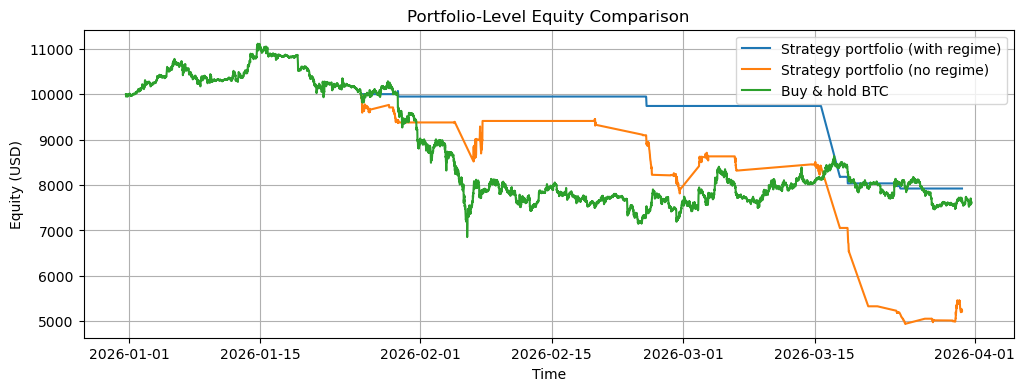

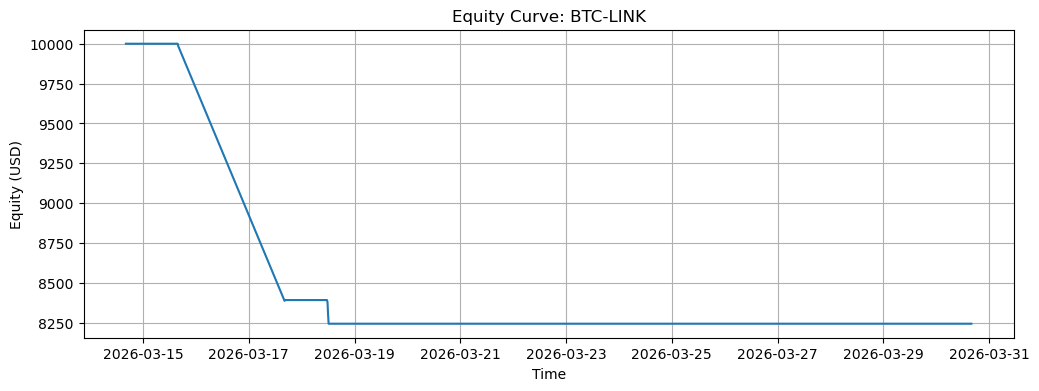

{'pair': 'BTC-LINK',
 'beta': 0.19111660959179663,
 'initial_capital': 10000.0,
 'final_equity': 8243.708957068206,
 'total_pnl': -1756.291042931793,
 'gross_pnl': -1700.2180142383231,
 'total_fees': 56.07302869346988,
 'sharpe': -9.518902655062222,
 'max_drawdown': -0.17562910429317946,
 'avg_turnover': 0.02677408643555773,
 'num_trades': 2,
 'win_rate': 0.0}

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(portfolio_bt["df"].index, portfolio_bt["df"]["equity"], label="Strategy portfolio (with regime)")
plt.plot(portfolio_bt_no_regime["df"].index, portfolio_bt_no_regime["df"]["equity"], label="Strategy portfolio (no regime)")
plt.plot(btc_bh_bt["df"].index, btc_bh_bt["df"]["equity"], label="Buy & hold BTC")
plt.title("Portfolio-Level Equity Comparison")
plt.xlabel("Time")
plt.ylabel("Equity (USD)")
plt.legend()
plt.grid(True)
plt.show()

if not stats_df.empty:
    best_pair = stats_df.iloc[0]["pair"]
    best_result = next(r for r in wf_results if r["pair"] == best_pair)["result"]
    best_bt_df = best_result["backtest"]["df"]

    plt.figure(figsize=(12, 4))
    plt.plot(best_bt_df.index, best_bt_df["equity"].values)
    plt.title(f"Equity Curve: {best_pair}")
    plt.xlabel("Time")
    plt.ylabel("Equity (USD)")
    plt.grid(True)
    plt.show()

    display(best_result["backtest"]["stats"])


## Trade-level analysis for the top-ranked pair

This section keeps the single best pair for qualitative inspection, while the paper's main quantitative comparison should rely on the **portfolio-level** results and the **BTC buy-and-hold** baseline above.


,entry_time,exit_time,direction,holding_minutes,pnl
0,2026-03-15 16:00:00,2026-03-17 16:30:00,short_spread,2910.0,-1607.935842
1,2026-03-18 11:45:00,2026-03-18 12:15:00,long_spread,30.0,-148.355201


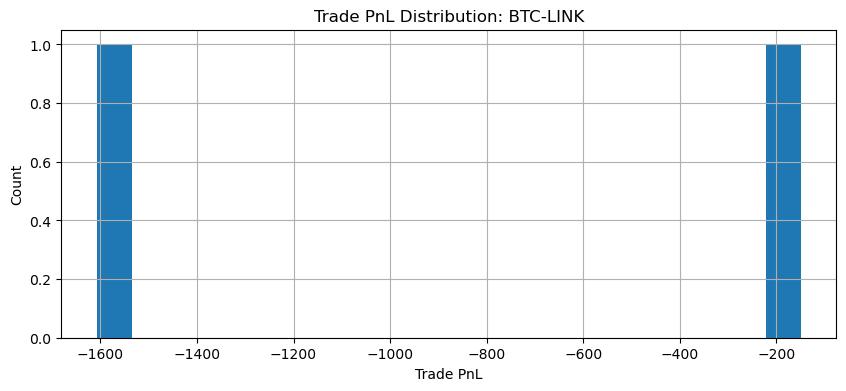

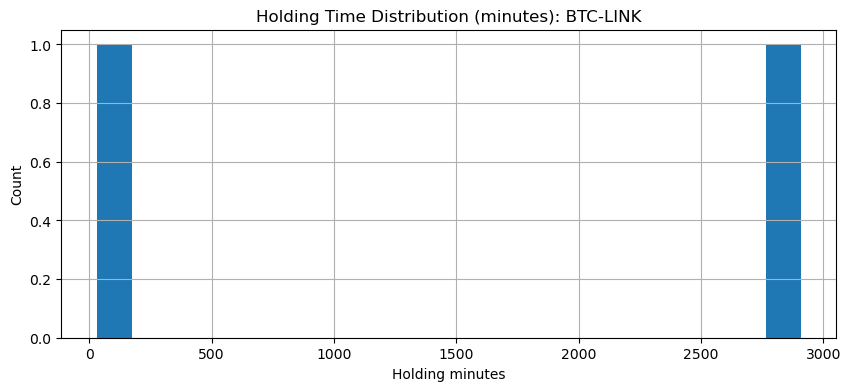

In [24]:
if not stats_df.empty:
    trade_log = build_trade_log(best_bt_df)
    display(trade_log.head(20))

    if not trade_log.empty:
        plt.figure(figsize=(10, 4))
        plt.hist(trade_log["pnl"], bins=20)
        plt.title(f"Trade PnL Distribution: {best_pair}")
        plt.xlabel("Trade PnL")
        plt.ylabel("Count")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.hist(trade_log["holding_minutes"], bins=20)
        plt.title(f"Holding Time Distribution (minutes): {best_pair}")
        plt.xlabel("Holding minutes")
        plt.ylabel("Count")
        plt.grid(True)
        plt.show()


## Research-paper limitations to state explicitly

- **Universe construction bias:** the universe is based on current large-cap assets with Binance USDT listings, so the study may contain survivorship / availability bias.
- **Selection / snooping risk:** many pairs and parameter combinations are evaluated, so strong performance in one pair may reflect multiple-testing effects.
- **Execution simplification:** fees and slippage are modeled, but funding rates, liquidation effects, and richer microstructure frictions are not.
- **Portfolio construction choice:** the portfolio result shown here is an **equal-weight average across available pair return streams**; different capital allocation schemes may lead to different outcomes.
- **Interpretation:** ADF rejection on a Kalman-filter-derived spread and Engle–Granger screening should be interpreted as operational filters for tradability, not as proof of a permanent economic relationship.
